# Notebook 06: Stress Test & Regulatory Capital (SCR)

## Overview
This notebook translates the stochastic mortality projections into regulatory capital metrics and performs stress testing for FINMA/SST and Solvency II compliance.

## Objectives
1. **Regulatory Capital (SCR)**: Compute VaR 99.5% (Solvency II) and Expected Shortfall 99.0% (SST) for the full cluster.
2. **Reverse Stress Test**: Determine the critical mortality shock $\delta^*$ that exhausts the SCR buffer (FINMA methodology).
3. **Model-Based Stress Test**: Inject a mortality shock in the $\Delta K_t$ domain and observe the model's transient response.
4. **Comparison with Project 04**: Benchmark against the unconstrained LSTM results.


## 6.1: Setup & Asset Loading

In [1]:
import sys
sys.path.append('../src')
from reproducibility import set_seed
set_seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, logging, warnings
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)

from style_config import set_style, save_dual, COUNTRIES, COUNTRY_COLORS
set_style("notebook")

PROCESSED_DIR = "../data/processed/"

# Load forecasting assets
with open(os.path.join(PROCESSED_DIR, "forecasting_assets.pkl"), "rb") as f:
    forecast = pickle.load(f)

# Load training metadata
with open(os.path.join(PROCESSED_DIR, "training_meta.pkl"), "rb") as f:
    meta = pickle.load(f)

e0_male = forecast['e0_male']          # (1000, 31, 6)
e0_female = forecast['e0_female']
e0_male_mbc = forecast['e0_male_mbc']
e0_female_mbc = forecast['e0_female_mbc']
forecast_years = forecast['forecast_years']
countries = forecast['countries']

print(f"Loaded: {e0_male.shape[0]} sims, {e0_male.shape[1]} years, {e0_male.shape[2]} countries")
print(f"Forecast period: {forecast_years[0]}-{forecast_years[-1]}")


/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loaded: 1000 sims, 31 years, 6 countries
Forecast period: 2020-2050


## 6.2: Regulatory Capital — SCR (VaR & ES)

We compute the Solvency Capital Requirement for longevity risk using two regulatory standards:
- **VaR 99.5%** (Solvency II): the 99.5th percentile of the $e_0$ distribution at 2050.
- **Expected Shortfall 99.0%** (SST/FINMA): the average of all simulations beyond the 99th percentile.

The SCR is defined as the excess life expectancy beyond the median — the additional years of life that the insurer must reserve for.

In [2]:
def compute_scr(e0_sims, year_idx=-1):
    """
    Compute VaR 99.5% and ES 99.0% SCR for each country.
    
    SCR = tail metric - median (the excess longevity risk).
    """
    results = []
    for c_idx, code in enumerate(countries):
        e0_at_horizon = e0_sims[:, year_idx, c_idx]
        
        median = np.percentile(e0_at_horizon, 50)
        var_995 = np.percentile(e0_at_horizon, 99.5)
        
        # ES 99%: mean of top 1% of simulations
        threshold_99 = np.percentile(e0_at_horizon, 99)
        es_99 = e0_at_horizon[e0_at_horizon >= threshold_99].mean()
        
        scr_var = var_995 - median
        scr_es = es_99 - median
        
        results.append({
            "Country": COUNTRIES[code], "Code": code,
            "Median e0 (2050)": round(median, 2),
            "VaR 99.5%": round(var_995, 2),
            "ES 99.0%": round(es_99, 2),
            "SCR (VaR)": round(scr_var, 3),
            "SCR (ES)": round(scr_es, 3),
        })
    return pd.DataFrame(results)


print("SCR Computation (2050 horizon, AINN without MBC):")
print("=" * 80)

print("\n  MALE:")
df_scr_male = compute_scr(e0_male)
print(df_scr_male.to_string(index=False))

print("\n  FEMALE:")
df_scr_female = compute_scr(e0_female)
print(df_scr_female.to_string(index=False))


SCR Computation (2050 horizon, AINN without MBC):

  MALE:
     Country  Code  Median e0 (2050)  VaR 99.5%  ES 99.0%  SCR (VaR)  SCR (ES)
 Switzerland   CHE             82.01      85.59     85.77      3.579     3.760
      Sweden   SWE             81.69      85.35     85.54      3.666     3.854
      Norway   NOR             82.25      85.74     85.91      3.487     3.664
West Germany DEUTW             80.28      84.54     84.76      4.254     4.474
 Netherlands   NLD             80.99      84.90     85.10      3.905     4.107
       Japan   JPN             82.16      85.74     85.92      3.573     3.752

  FEMALE:
     Country  Code  Median e0 (2050)  VaR 99.5%  ES 99.0%  SCR (VaR)  SCR (ES)
 Switzerland   CHE             86.04      88.92     88.96      2.877     2.919
      Sweden   SWE             85.55      88.73     88.77      3.176     3.223
      Norway   NOR             85.79      88.82     88.87      3.032     3.076
West Germany DEUTW             85.06      88.54     88.59    

## 6.3: SCR Visualisation (Switzerland Case Study)

Distribution of Swiss life expectancy at 2050 with VaR and ES thresholds marked.

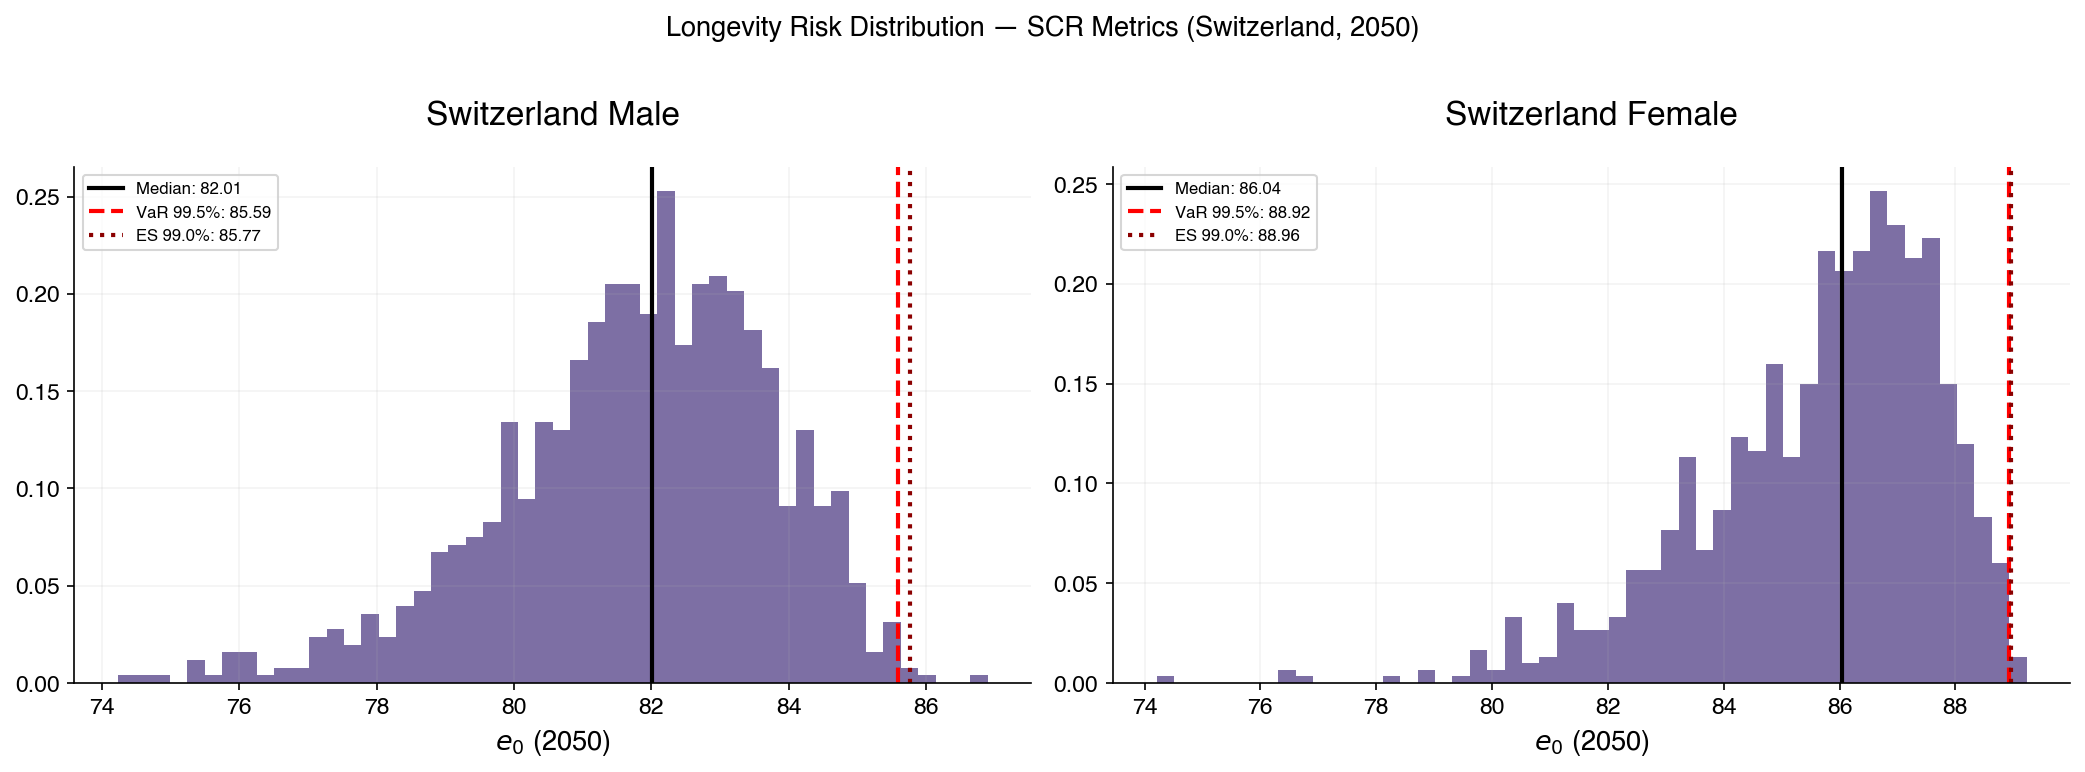

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
che_idx = countries.index('CHE')

for sex_idx, (sex, e0_arr) in enumerate([('Male', e0_male), ('Female', e0_female)]):
    ax = axes[sex_idx]
    e0_2050 = e0_arr[:, -1, che_idx]
    
    ax.hist(e0_2050, bins=50, color=COUNTRY_COLORS['CHE'], alpha=0.7, density=True)
    
    median = np.percentile(e0_2050, 50)
    var_995 = np.percentile(e0_2050, 99.5)
    es_99_thresh = np.percentile(e0_2050, 99)
    es_99 = e0_2050[e0_2050 >= es_99_thresh].mean()
    
    ax.axvline(median, color='black', linewidth=2, label=f'Median: {median:.2f}')
    ax.axvline(var_995, color='red', linewidth=2, linestyle='--', label=f'VaR 99.5%: {var_995:.2f}')
    ax.axvline(es_99, color='darkred', linewidth=2, linestyle=':', label=f'ES 99.0%: {es_99:.2f}')
    
    ax.set_xlabel("$e_0$ (2050)")
    ax.set_title(f"Switzerland {sex}")
    ax.legend(fontsize=8)

fig.suptitle("Longevity Risk Distribution — SCR Metrics (Switzerland, 2050)", fontsize=13, y=1.02)
plt.tight_layout()
save_dual(fig, "fig15_scr_distribution_che")
plt.show()


## 6.4: Reverse Stress Test (FINMA Methodology)

Instead of applying an arbitrary shock and measuring its impact, we invert the problem: **what is the critical mortality reduction $\delta^*$ that would exhaust the SCR buffer?**

This is the standard reverse stress test required by FINMA under the SST framework.

Method:
1. Compute the relationship between a uniform mortality reduction $\delta$ and the resulting $\Delta e_0$.
2. Find $\delta^*$ such that $\Delta e_0(\delta^*) =$ SCR (ES 99.0%).

In [4]:
def reverse_stress_test(sex, code='CHE'):
    """
    Compute the critical shock threshold delta* for a given country.
    Tests multiple shock levels to verify linearity, then extrapolates.
    """
    from scipy.stats import linregress
    
    c_idx = countries.index(code)
    
    # Load observed mortality at 2020
    log_mx_obs = np.load(os.path.join(PROCESSED_DIR, f"{code}_log_mx_{sex}.npy"))
    log_mx_2020 = log_mx_obs[:, -1]
    mx_2020 = np.exp(log_mx_2020)
    
    # Baseline e0 at 2020
    def calc_e0(mx):
        qx = 1.0 - np.exp(-mx)
        qx[-1] = 1.0
        px = 1.0 - qx
        lx = np.concatenate(([1.0], np.cumprod(px[:-1])))
        lx_ext = np.append(lx, 0.0)
        return np.sum((lx_ext[:-1] + lx_ext[1:]) / 2.0)
    
    e0_baseline = calc_e0(mx_2020)
    
    # Test multiple shock levels
    deltas = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
    delta_e0s = []
    for d in deltas:
        mx_shocked = mx_2020 * (1 - d)
        e0_shocked = calc_e0(mx_shocked)
        delta_e0s.append(e0_shocked - e0_baseline)
    
    # Linear regression to verify linearity
    slope, intercept, r_value, _, _ = linregress(deltas, delta_e0s)
    
    # Get SCR (ES 99.0%) for this country
    e0_2050 = forecast[f'e0_{sex}'][:, -1, c_idx]
    median = np.percentile(e0_2050, 50)
    es_99_thresh = np.percentile(e0_2050, 99)
    es_99 = e0_2050[e0_2050 >= es_99_thresh].mean()
    scr_es = es_99 - median
    
    # Critical threshold: delta* = SCR / slope
    delta_star = scr_es / slope if slope > 0 else float('nan')
    
    # 10% shock as % of SCR
    shock_10_impact = slope * 0.10
    shock_10_pct_scr = (shock_10_impact / scr_es * 100) if scr_es > 0 else float('nan')
    
    return {
        "Country": COUNTRIES[code], "Sex": sex.capitalize(),
        "SCR (ES 99.0%)": round(scr_es, 3),
        "delta*": round(delta_star * 100, 1),  # as percentage
        "Linearity R²": round(r_value**2, 4),
        "10% Shock Impact": round(shock_10_impact, 3),
        "10% as % of SCR": round(shock_10_pct_scr, 1),
    }


# Run for all countries and both sexes
print("Reverse Stress Test (FINMA/SST Methodology):")
print("=" * 90)

rst_results = []
for sex in ['male', 'female']:
    for code in countries:
        rst = reverse_stress_test(sex, code)
        rst_results.append(rst)

df_rst = pd.DataFrame(rst_results)
print(df_rst.to_string(index=False))

# Highlight Switzerland
print(f"\n--- Switzerland Summary ---")
che_m = df_rst[(df_rst['Country']=='Switzerland') & (df_rst['Sex']=='Male')].iloc[0]
che_f = df_rst[(df_rst['Country']=='Switzerland') & (df_rst['Sex']=='Female')].iloc[0]
print(f"  Male:   delta* = {che_m['delta*']}% | SCR(ES) = +{che_m['SCR (ES 99.0%)']} yrs | 10% shock = {che_m['10% as % of SCR']}% of buffer")
print(f"  Female: delta* = {che_f['delta*']}% | SCR(ES) = +{che_f['SCR (ES 99.0%)']} yrs | 10% shock = {che_f['10% as % of SCR']}% of buffer")


Reverse Stress Test (FINMA/SST Methodology):
     Country    Sex  SCR (ES 99.0%)  delta*  Linearity R²  10% Shock Impact  10% as % of SCR
 Switzerland   Male           3.760    45.3        0.9996             0.830             22.1
      Sweden   Male           3.854    45.5        0.9996             0.847             22.0
      Norway   Male           3.664    45.0        0.9996             0.814             22.2
West Germany   Male           4.474    46.7        0.9995             0.957             21.4
 Netherlands   Male           4.107    46.3        0.9995             0.888             21.6
       Japan   Male           3.752    45.1        0.9997             0.831             22.2
 Switzerland Female           2.919    48.5        0.9998             0.602             20.6
      Sweden Female           3.223    49.9        0.9998             0.646             20.1
      Norway Female           3.076    49.1        0.9998             0.626             20.3
West Germany Female      

## 6.5: Model-Based Stress Test (Shock in $\Delta K_t$ Domain)

Unlike the reverse stress test (which applies a post-hoc shock to $m_x$), the model-based stress test translates a mortality shock into the $\Delta K_t$ domain, injects it into the LSTM's input window, and re-executes the recursive forecast. This tests:
- Does the model amplify or dampen the shock?
- How long does it take for the shock to "exit" the sliding window?
- Is the model stable under perturbation?

In [5]:
from tensorflow import keras
import joblib

# Load model and scaler
MODELS_DIR = "../models/"
champion_model = keras.models.load_model(os.path.join(MODELS_DIR, "ainn_champion.keras"), compile=False)
scaler = joblib.load(os.path.join(MODELS_DIR, "scaler_joint.pkl"))

with open(os.path.join(PROCESSED_DIR, "li_lee_params.pkl"), "rb") as f:
    bundle = pickle.load(f)
feature_matrices = bundle["feature_matrices"]
common_factors = bundle["common_factors"]
LOOKBACK = meta["lookback"]

def get_initial_sequence(sex):
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([feature_matrices[sex],
                            np.full(len(feature_matrices[sex]), sex_indicator)])
    return scaler.transform(data)[-LOOKBACK:]


def forecast_with_shock(sex, shock_delta_kt, shock_year=5, n_sims=200, n_steps=30):
    """
    Inject a shock in delta_Kt at a specific forecast year and observe response.
    
    shock_delta_kt: the anomalous variation to inject (in scaled space).
    shock_year: at which forecast step to inject (0-indexed).
    """
    init_seq = get_initial_sequence(sex)
    n_features = init_seq.shape[-1]
    
    # Baseline (no shock)
    baseline_kt = np.zeros((n_sims, n_steps))
    shocked_kt = np.zeros((n_sims, n_steps))
    
    for sim in range(n_sims):
        # Baseline
        seq = init_seq.copy()
        for step in range(n_steps):
            inp = tf.convert_to_tensor(seq[np.newaxis, ...], dtype=tf.float32)
            pred = champion_model(inp, training=True).numpy().reshape(n_features)
            baseline_kt[sim, step] = pred[0]
            seq = np.roll(seq, -1, axis=0)
            seq[-1] = pred
        
        # Shocked
        seq = init_seq.copy()
        for step in range(n_steps):
            inp = tf.convert_to_tensor(seq[np.newaxis, ...], dtype=tf.float32)
            pred = champion_model(inp, training=True).numpy().reshape(n_features)
            if step == shock_year:
                pred[0] += shock_delta_kt  # Inject shock
            shocked_kt[sim, step] = pred[0]
            seq = np.roll(seq, -1, axis=0)
            seq[-1] = pred
    
    return baseline_kt, shocked_kt


# Run stress test: inject a large negative shock (mortality improvement) at year 5 (=2026)
# A shock of -2.0 in scaled space corresponds to ~2 std deviations of delta_Kt
print("Running model-based stress test (200 sims, shock at year 2026)...")
baseline_kt, shocked_kt = forecast_with_shock('male', shock_delta_kt=-2.0, shock_year=5, n_sims=200)

# Compute cumulative effect
baseline_cumsum = np.cumsum(baseline_kt, axis=1)
shocked_cumsum = np.cumsum(shocked_kt, axis=1)
diff = shocked_cumsum - baseline_cumsum  # Difference = shock effect

print(f"Shock injected at year 2026 (step 5)")
print(f"Immediate effect (step 5): {np.mean(diff[:, 5]):.3f}")
print(f"Effect at 2035 (step 14): {np.mean(diff[:, 14]):.3f}")
print(f"Effect at 2050 (step 29): {np.mean(diff[:, 29]):.3f}")
print(f"Convergence: {'YES (effect stable)' if abs(np.mean(diff[:, 29]) - np.mean(diff[:, 14])) < 0.5 else 'NO (effect growing)'}")


Running model-based stress test (200 sims, shock at year 2026)...
Shock injected at year 2026 (step 5)
Immediate effect (step 5): -1.886
Effect at 2035 (step 14): -1.446
Effect at 2050 (step 29): -1.559
Convergence: YES (effect stable)


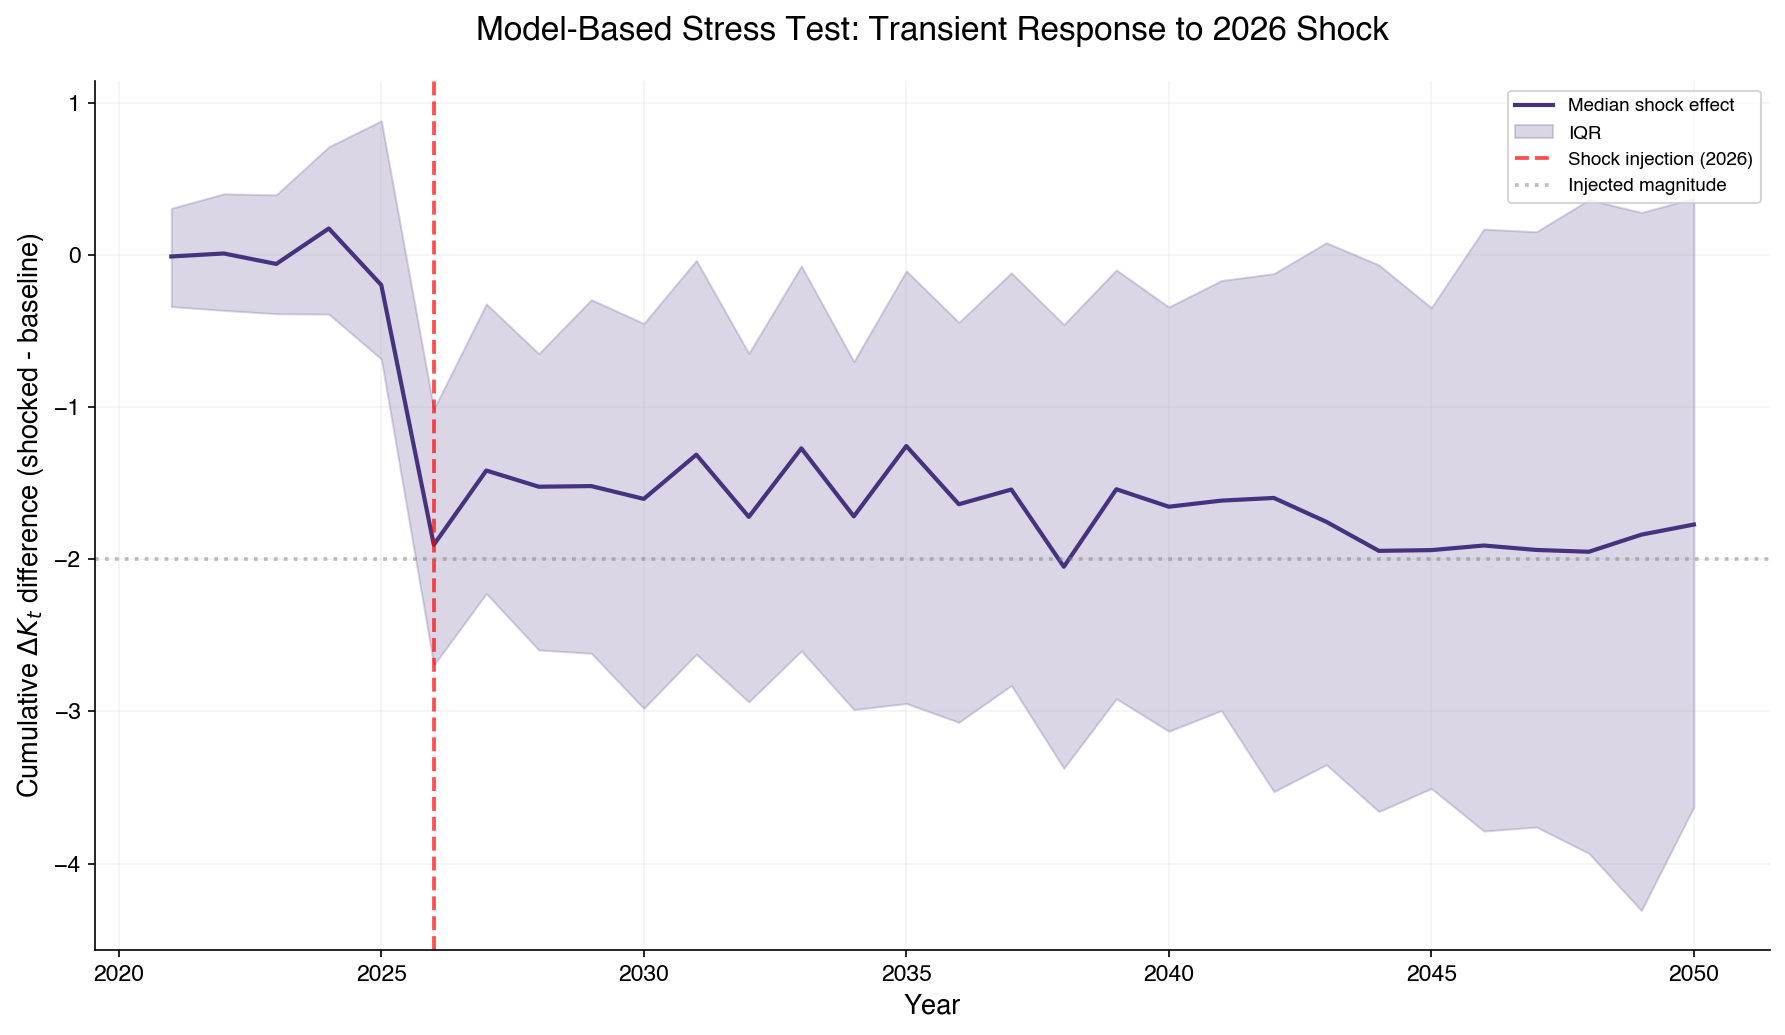


Max amplification ratio: 1.02x
Verdict: STABLE (no explosive amplification)


In [6]:
# Visualise transient response
fig, ax = plt.subplots()

years_forecast = forecast_years[1:]  # 2021-2050
median_diff = np.median(diff, axis=0)
p25 = np.percentile(diff, 25, axis=0)
p75 = np.percentile(diff, 75, axis=0)

ax.plot(years_forecast, median_diff, color=COUNTRY_COLORS['CHE'], linewidth=2, label='Median shock effect')
ax.fill_between(years_forecast, p25, p75, alpha=0.2, color=COUNTRY_COLORS['CHE'], label='IQR')
ax.axvline(x=2026, color='red', linestyle='--', alpha=0.7, label='Shock injection (2026)')
ax.axhline(y=-2.0, color='grey', linestyle=':', alpha=0.5, label='Injected magnitude')
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative $\Delta K_t$ difference (shocked - baseline)")
ax.set_title("Model-Based Stress Test: Transient Response to 2026 Shock")
ax.legend(fontsize=9)

plt.tight_layout()
save_dual(fig, "fig16_model_stress_test")
plt.show()

# Stability verdict
max_amplification = np.max(np.abs(median_diff)) / 2.0  # Relative to injected shock
print(f"\nMax amplification ratio: {max_amplification:.2f}x")
print(f"Verdict: {'STABLE (no explosive amplification)' if max_amplification < 2.0 else 'UNSTABLE'}")


## 6.6: Persistence

In [7]:
scr_results = {
    "scr_male": df_scr_male.to_dict(),
    "scr_female": df_scr_female.to_dict(),
    "reverse_stress_test": df_rst.to_dict(),
    "stress_test_diff_median": median_diff.tolist(),
    "stress_test_max_amplification": float(max_amplification),
}

with open(os.path.join(PROCESSED_DIR, "scr_results.pkl"), "wb") as f:
    pickle.dump(scr_results, f)

df_scr_male.to_csv(os.path.join(PROCESSED_DIR, "scr_male.csv"), index=False)
df_scr_female.to_csv(os.path.join(PROCESSED_DIR, "scr_female.csv"), index=False)
df_rst.to_csv(os.path.join(PROCESSED_DIR, "reverse_stress_test.csv"), index=False)

print("SCR and stress test results saved.")
print(f"\nNotebook 06 complete. Project 05 pipeline finished.")


SCR and stress test results saved.

Notebook 06 complete. Project 05 pipeline finished.
